In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama


In [6]:
model = ChatOllama(model = 'qwen3:4b', temperature=0)
response = model.invoke('what is 2+2?')
print(response.content)

The answer to **2 + 2** is **4**.  

This is a fundamental result in basic arithmetic (addition of whole numbers). In all standard mathematical contexts (like elementary math, programming, or real-world calculations), **2 + 2 = 4**.  

### Why?
- **2** represents two units.
- Adding **two more units** (2) gives a total of **four units** (4).  

This is consistent across all number systems (decimal, binary, etc.) and real-world applications. 😊  

*If you meant something else (e.g., a different context like programming, modular arithmetic, or a trick question), feel free to clarify—I’ll help you figure it out!*


In [10]:
class State(TypedDict):
    question: str
    answer: str

In [17]:
def llm(St: State) -> State:
    prompt = St['question'] 
    answer = model.invoke(prompt)

    St['answer'] = answer.content
    return St

In [18]:
graph = StateGraph(State)

graph.add_node("LLM", llm)

graph.add_edge(START, 'LLM')
graph.add_edge('LLM', END)

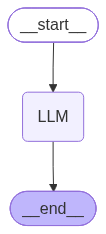

In [19]:
graph.compile()

In [20]:
agent = graph.compile()

In [21]:
intial_state = {'question': 'Give me one line answer, what is the main goal of huminaty in this world'}
final_state = agent.invoke(intial_state)

In [22]:
print(final_state)

{'question': 'Give me one line answer, what is the main goal of huminaty in this world', 'answer': 'The main goal of humanity in this world is to live in harmony and achieve collective well-being for all people and the planet.'}


In [23]:
print(final_state['answer'])

The main goal of humanity in this world is to live in harmony and achieve collective well-being for all people and the planet.
